# Principal Component Analysis with Cancer Data

In [1]:
#Import all the necessary modules
#Import all the necessary modules
import pandas as pd
import numpy as np
import os
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler


from sklearn.decomposition import PCA
from scipy.stats import zscore

# Q1. Load the Data file into Python DataFrame and view top 10 rows

In [3]:
  # Id columns is to identify rows hence can be skipped in analysis
  # All columns have numerical values
  # Class would be the target variable. Should be removed when PCA is done

In [4]:
cancer_df = pd.read_csv("cancer.csv")

In [5]:
#Get Top 10 Rows
cancer_df.head(10)

,ID,ClumpThickness,Cell Size,Cell Shape,Marginal Adhesion,Single Epithelial Cell Size,Bare Nuclei,Normal Nucleoli,Bland Chromatin,Mitoses,Class
0,1000025,5,1,1,1,2,1,3,1,1,2
1,1002945,5,4,4,5,7,10,3,2,1,2
2,1015425,3,1,1,1,2,2,3,1,1,2
3,1016277,6,8,8,1,3,4,3,7,1,2
4,1017023,4,1,1,3,2,1,3,1,1,2
5,1017122,8,10,10,8,7,10,9,7,1,4
6,1018099,1,1,1,1,2,10,3,1,1,2
7,1018561,2,1,2,1,2,1,3,1,1,2
8,1033078,2,1,1,1,2,1,1,1,5,2
9,1033078,4,2,1,1,2,1,2,1,1,2


# Q2 Print the datatypes of each column and the shape of the dataset. Perform descriptive analysis 

In [6]:
cancer_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 699 entries, 0 to 698
Data columns (total 11 columns):
ID                             699 non-null int64
ClumpThickness                 699 non-null int64
Cell Size                      699 non-null int64
Cell Shape                     699 non-null int64
Marginal Adhesion              699 non-null int64
Single Epithelial Cell Size    699 non-null int64
Bare Nuclei                    699 non-null object
Normal Nucleoli                699 non-null int64
Bland Chromatin                699 non-null int64
Mitoses                        699 non-null int64
Class                          699 non-null int64
dtypes: int64(10), object(1)
memory usage: 60.1+ KB


In [7]:
cancer_df.shape

(699, 11)

In [8]:
cancer_df.describe()

,ID,ClumpThickness,Cell Size,Cell Shape,Marginal Adhesion,Single Epithelial Cell Size,Normal Nucleoli,Bland Chromatin,Mitoses,Class
count,6.990000e+02,699.000000,699.000000,699.000000,699.000000,699.000000,699.000000,699.000000,699.000000,699.000000
mean,1.071704e+06,4.417740,3.134478,3.207439,2.806867,3.216023,3.437768,2.866953,1.589413,2.689557
std,6.170957e+05,2.815741,3.051459,2.971913,2.855379,2.214300,2.438364,3.053634,1.715078,0.951273
min,6.163400e+04,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,2.000000
25%,8.706885e+05,2.000000,1.000000,1.000000,1.000000,2.000000,2.000000,1.000000,1.000000,2.000000
50%,1.171710e+06,4.000000,1.000000,1.000000,1.000000,2.000000,3.000000,1.000000,1.000000,2.000000
75%,1.238298e+06,6.000000,5.000000,5.000000,4.000000,4.000000,5.000000,4.000000,1.000000,4.000000
max,1.345435e+07,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,4.000000


# Q3 Check for missing value check, incorrect data, duplicate data and perform imputation with mean, median, mode as necessary.


In [9]:
# We could see "?" values in column, this should be removed from data set

# Check for missing value in any other column

In [10]:
#Replace '?' with NaN
cancer_df = cancer_df.replace('?', np.nan)

In [11]:
#Check NaN in the dataset
cancer_df.isna().sum()

ID                              0
ClumpThickness                  0
Cell Size                       0
Cell Shape                      0
Marginal Adhesion               0
Single Epithelial Cell Size     0
Bare Nuclei                    16
Normal Nucleoli                 0
Bland Chromatin                 0
Mitoses                         0
Class                           0
dtype: int64

In [12]:
# fill missing values with mean column values
cancer_df = cancer_df.apply(lambda x: x.fillna(x.median()),axis=0)

In [13]:
cancer_df.isna().sum()

ID                             0
ClumpThickness                 0
Cell Size                      0
Cell Shape                     0
Marginal Adhesion              0
Single Epithelial Cell Size    0
Bare Nuclei                    0
Normal Nucleoli                0
Bland Chromatin                0
Mitoses                        0
Class                          0
dtype: int64

In [14]:
# No missing values found. So let us try to remove ? from bare nuclei column

# Get count of rows having ?


In [15]:
# 16 values are corrupted. We can either delete them as it forms roughly 2% of data.
# Here we would like to impute it with suitable values

In [16]:
# converting the 'Bare Nuclei' column from object / string type to int 64
cancer_df['Bare Nuclei'] = cancer_df['Bare Nuclei'].astype('int64') 

In [17]:
#Get Duplicate row Count
print("Total Number of duplicate rows : {0}".format(cancer_df.duplicated().sum()))

Total Number of duplicate rows : 9


In [18]:
#Drop duplicate
cancer_df.drop_duplicates(keep='first',inplace=True)

In [19]:
cancer_df.shape

(690, 11)

# Q4. Perform bi variate analysis including correlation & pairplots. 


In [20]:
# Check for correlation of variable

In [21]:
# Cell size shows high significance with cell shape,marginal adhesion, single epithelial cell size,bare nuclei, normal nucleoli 
# and bland chromatin
# Target variable shows high correlation with most of these variables

In [65]:
#Now let's do the individual column analysis with respect to the class column using Box Plot

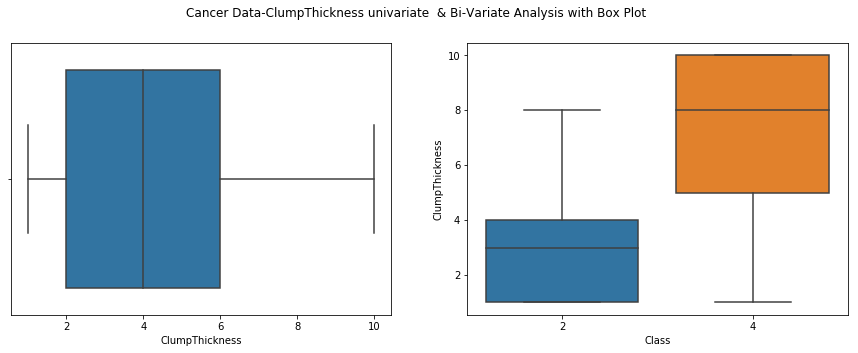

In [66]:
a4_dims = (15, 5)
fig, ax = plt.subplots(nrows=1, ncols=2,figsize=a4_dims)
fig.subplots_adjust(hspace=0.5)
fig.suptitle('Cancer Data-ClumpThickness univariate  & Bi-Variate Analysis with Box Plot')

sns.boxplot(data=cancer_df, x="ClumpThickness",ax=ax[0]);
sns.boxplot(data=cancer_df, y="ClumpThickness",x="Class",ax=ax[1]);



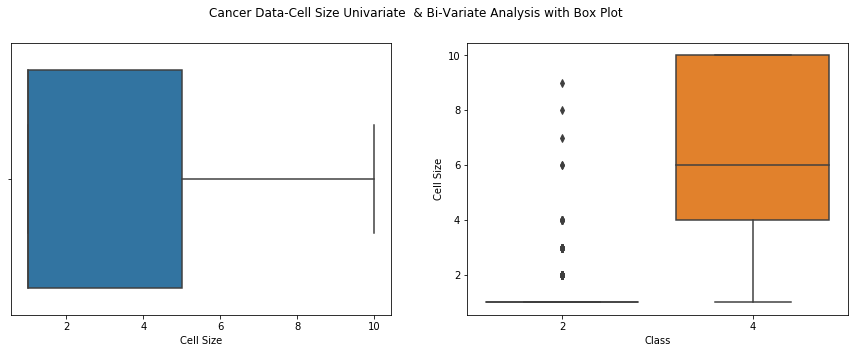

In [67]:
a4_dims = (15, 5)
fig, ax = plt.subplots(nrows=1, ncols=2,figsize=a4_dims)
fig.subplots_adjust(hspace=0.5)
fig.suptitle('Cancer Data-Cell Size Univariate  & Bi-Variate Analysis with Box Plot')

sns.boxplot(data=cancer_df, x="Cell Size",ax=ax[0]);
sns.boxplot(data=cancer_df, y="Cell Size",x="Class",ax=ax[1]);

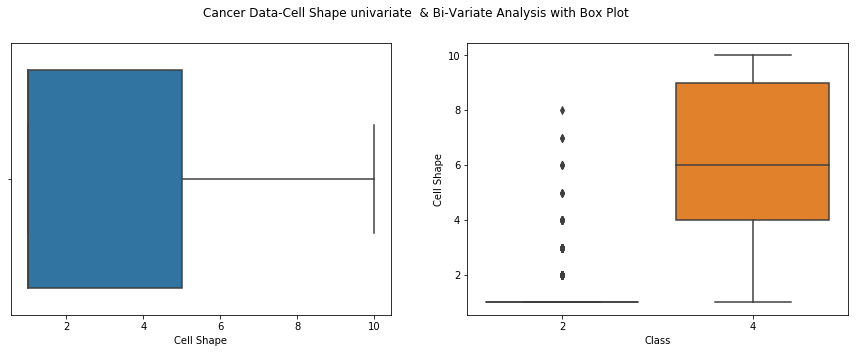

In [68]:
a4_dims = (15, 5)
fig, ax = plt.subplots(nrows=1, ncols=2,figsize=a4_dims)
fig.subplots_adjust(hspace=0.5)
fig.suptitle('Cancer Data-Cell Shape univariate  & Bi-Variate Analysis with Box Plot')

sns.boxplot(data=cancer_df, x="Cell Shape",ax=ax[0]);
sns.boxplot(data=cancer_df, y="Cell Shape",x="Class",ax=ax[1]);

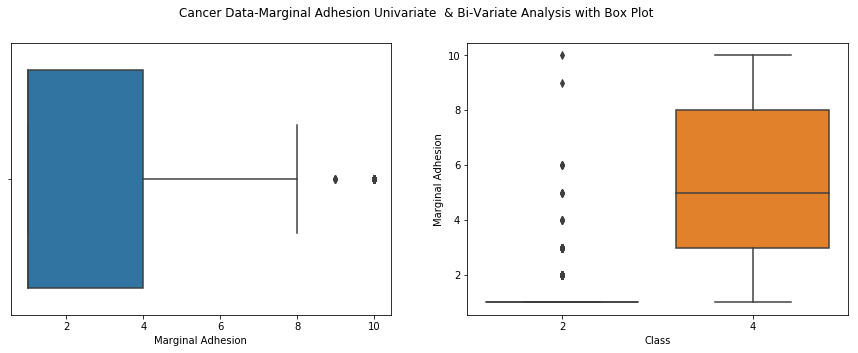

In [69]:
a4_dims = (15, 5)
fig, ax = plt.subplots(nrows=1, ncols=2,figsize=a4_dims)
fig.subplots_adjust(hspace=0.5)
fig.suptitle('Cancer Data-Marginal Adhesion Univariate  & Bi-Variate Analysis with Box Plot')

sns.boxplot(data=cancer_df, x="Marginal Adhesion",ax=ax[0]);
sns.boxplot(data=cancer_df, y="Marginal Adhesion",x="Class",ax=ax[1]);

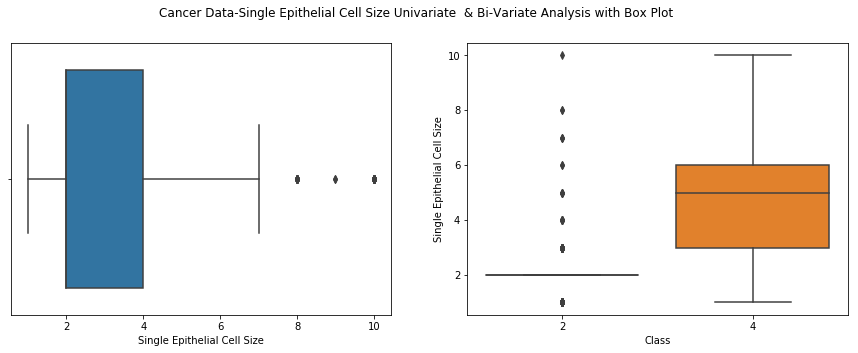

In [70]:
a4_dims = (15, 5)
fig, ax = plt.subplots(nrows=1, ncols=2,figsize=a4_dims)
fig.subplots_adjust(hspace=0.5)
fig.suptitle('Cancer Data-Single Epithelial Cell Size Univariate  & Bi-Variate Analysis with Box Plot')

sns.boxplot(data=cancer_df, x="Single Epithelial Cell Size",ax=ax[0]);
sns.boxplot(data=cancer_df, y="Single Epithelial Cell Size",x="Class",ax=ax[1]);

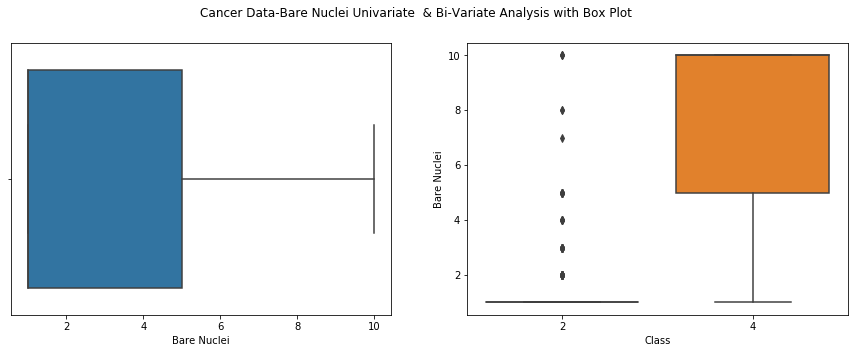

In [71]:
a4_dims = (15, 5)
fig, ax = plt.subplots(nrows=1, ncols=2,figsize=a4_dims)
fig.subplots_adjust(hspace=0.5)
fig.suptitle('Cancer Data-Bare Nuclei Univariate  & Bi-Variate Analysis with Box Plot')

sns.boxplot(data=cancer_df, x="Bare Nuclei",ax=ax[0]);
sns.boxplot(data=cancer_df, y="Bare Nuclei",x="Class",ax=ax[1]);

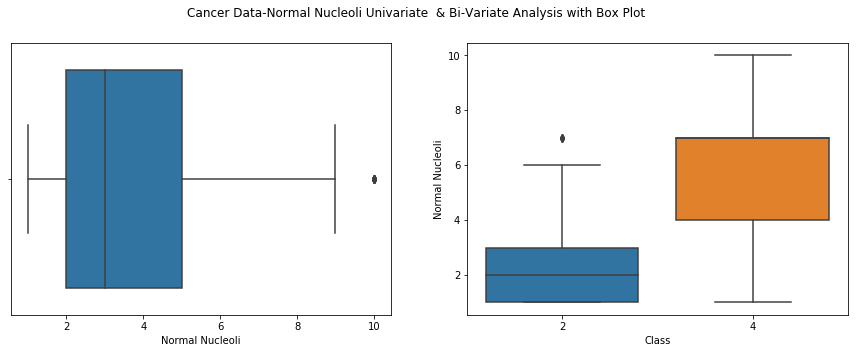

In [72]:
a4_dims = (15, 5)
fig, ax = plt.subplots(nrows=1, ncols=2,figsize=a4_dims)
fig.subplots_adjust(hspace=0.5)
fig.suptitle('Cancer Data-Normal Nucleoli Univariate  & Bi-Variate Analysis with Box Plot')

sns.boxplot(data=cancer_df, x="Normal Nucleoli",ax=ax[0]);
sns.boxplot(data=cancer_df, y="Normal Nucleoli",x="Class",ax=ax[1]);

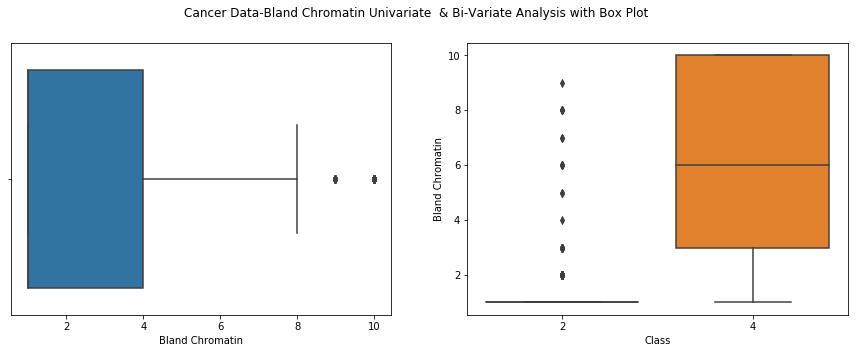

In [73]:
a4_dims = (15, 5)
fig, ax = plt.subplots(nrows=1, ncols=2,figsize=a4_dims)
fig.subplots_adjust(hspace=0.5)
fig.suptitle('Cancer Data-Bland Chromatin Univariate  & Bi-Variate Analysis with Box Plot')

sns.boxplot(data=cancer_df, x="Bland Chromatin",ax=ax[0]);
sns.boxplot(data=cancer_df, y="Bland Chromatin",x="Class",ax=ax[1]);

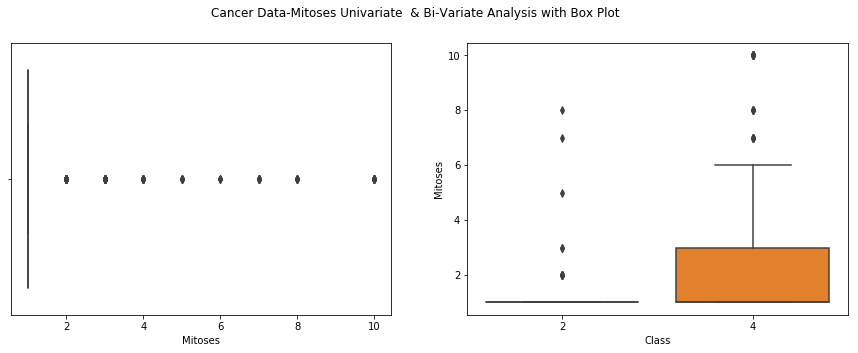

In [74]:
a4_dims = (15, 5)
fig, ax = plt.subplots(nrows=1, ncols=2,figsize=a4_dims)
fig.subplots_adjust(hspace=0.5)
fig.suptitle('Cancer Data-Mitoses Univariate  & Bi-Variate Analysis with Box Plot')

sns.boxplot(data=cancer_df, x="Mitoses",ax=ax[0]);
sns.boxplot(data=cancer_df, y="Mitoses",x="Class",ax=ax[1]);

In [75]:
#Let us check for pair plots

C:\ProgramData\Anaconda3\lib\site-packages\scipy\stats\stats.py:1713: FutureWarning: Using a non-tuple sequence for multidimensional indexing is deprecated; use `arr[tuple(seq)]` instead of `arr[seq]`. In the future this will be interpreted as an array index, `arr[np.array(seq)]`, which will result either in an error or a different result.
  return np.add.reduce(sorted[indexer] * weights, axis=axis) / sumval
C:\ProgramData\Anaconda3\lib\site-packages\statsmodels\nonparametric\kde.py:488: RuntimeWarning: invalid value encountered in true_divide
  binned = fast_linbin(X, a, b, gridsize) / (delta * nobs)
C:\ProgramData\Anaconda3\lib\site-packages\statsmodels\nonparametric\kdetools.py:34: RuntimeWarning: invalid value encountered in double_scalars
  FAC1 = 2*(np.pi*bw/RANGE)**2
C:\ProgramData\Anaconda3\lib\site-packages\numpy\core\fromnumeric.py:83: RuntimeWarning: invalid value encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)


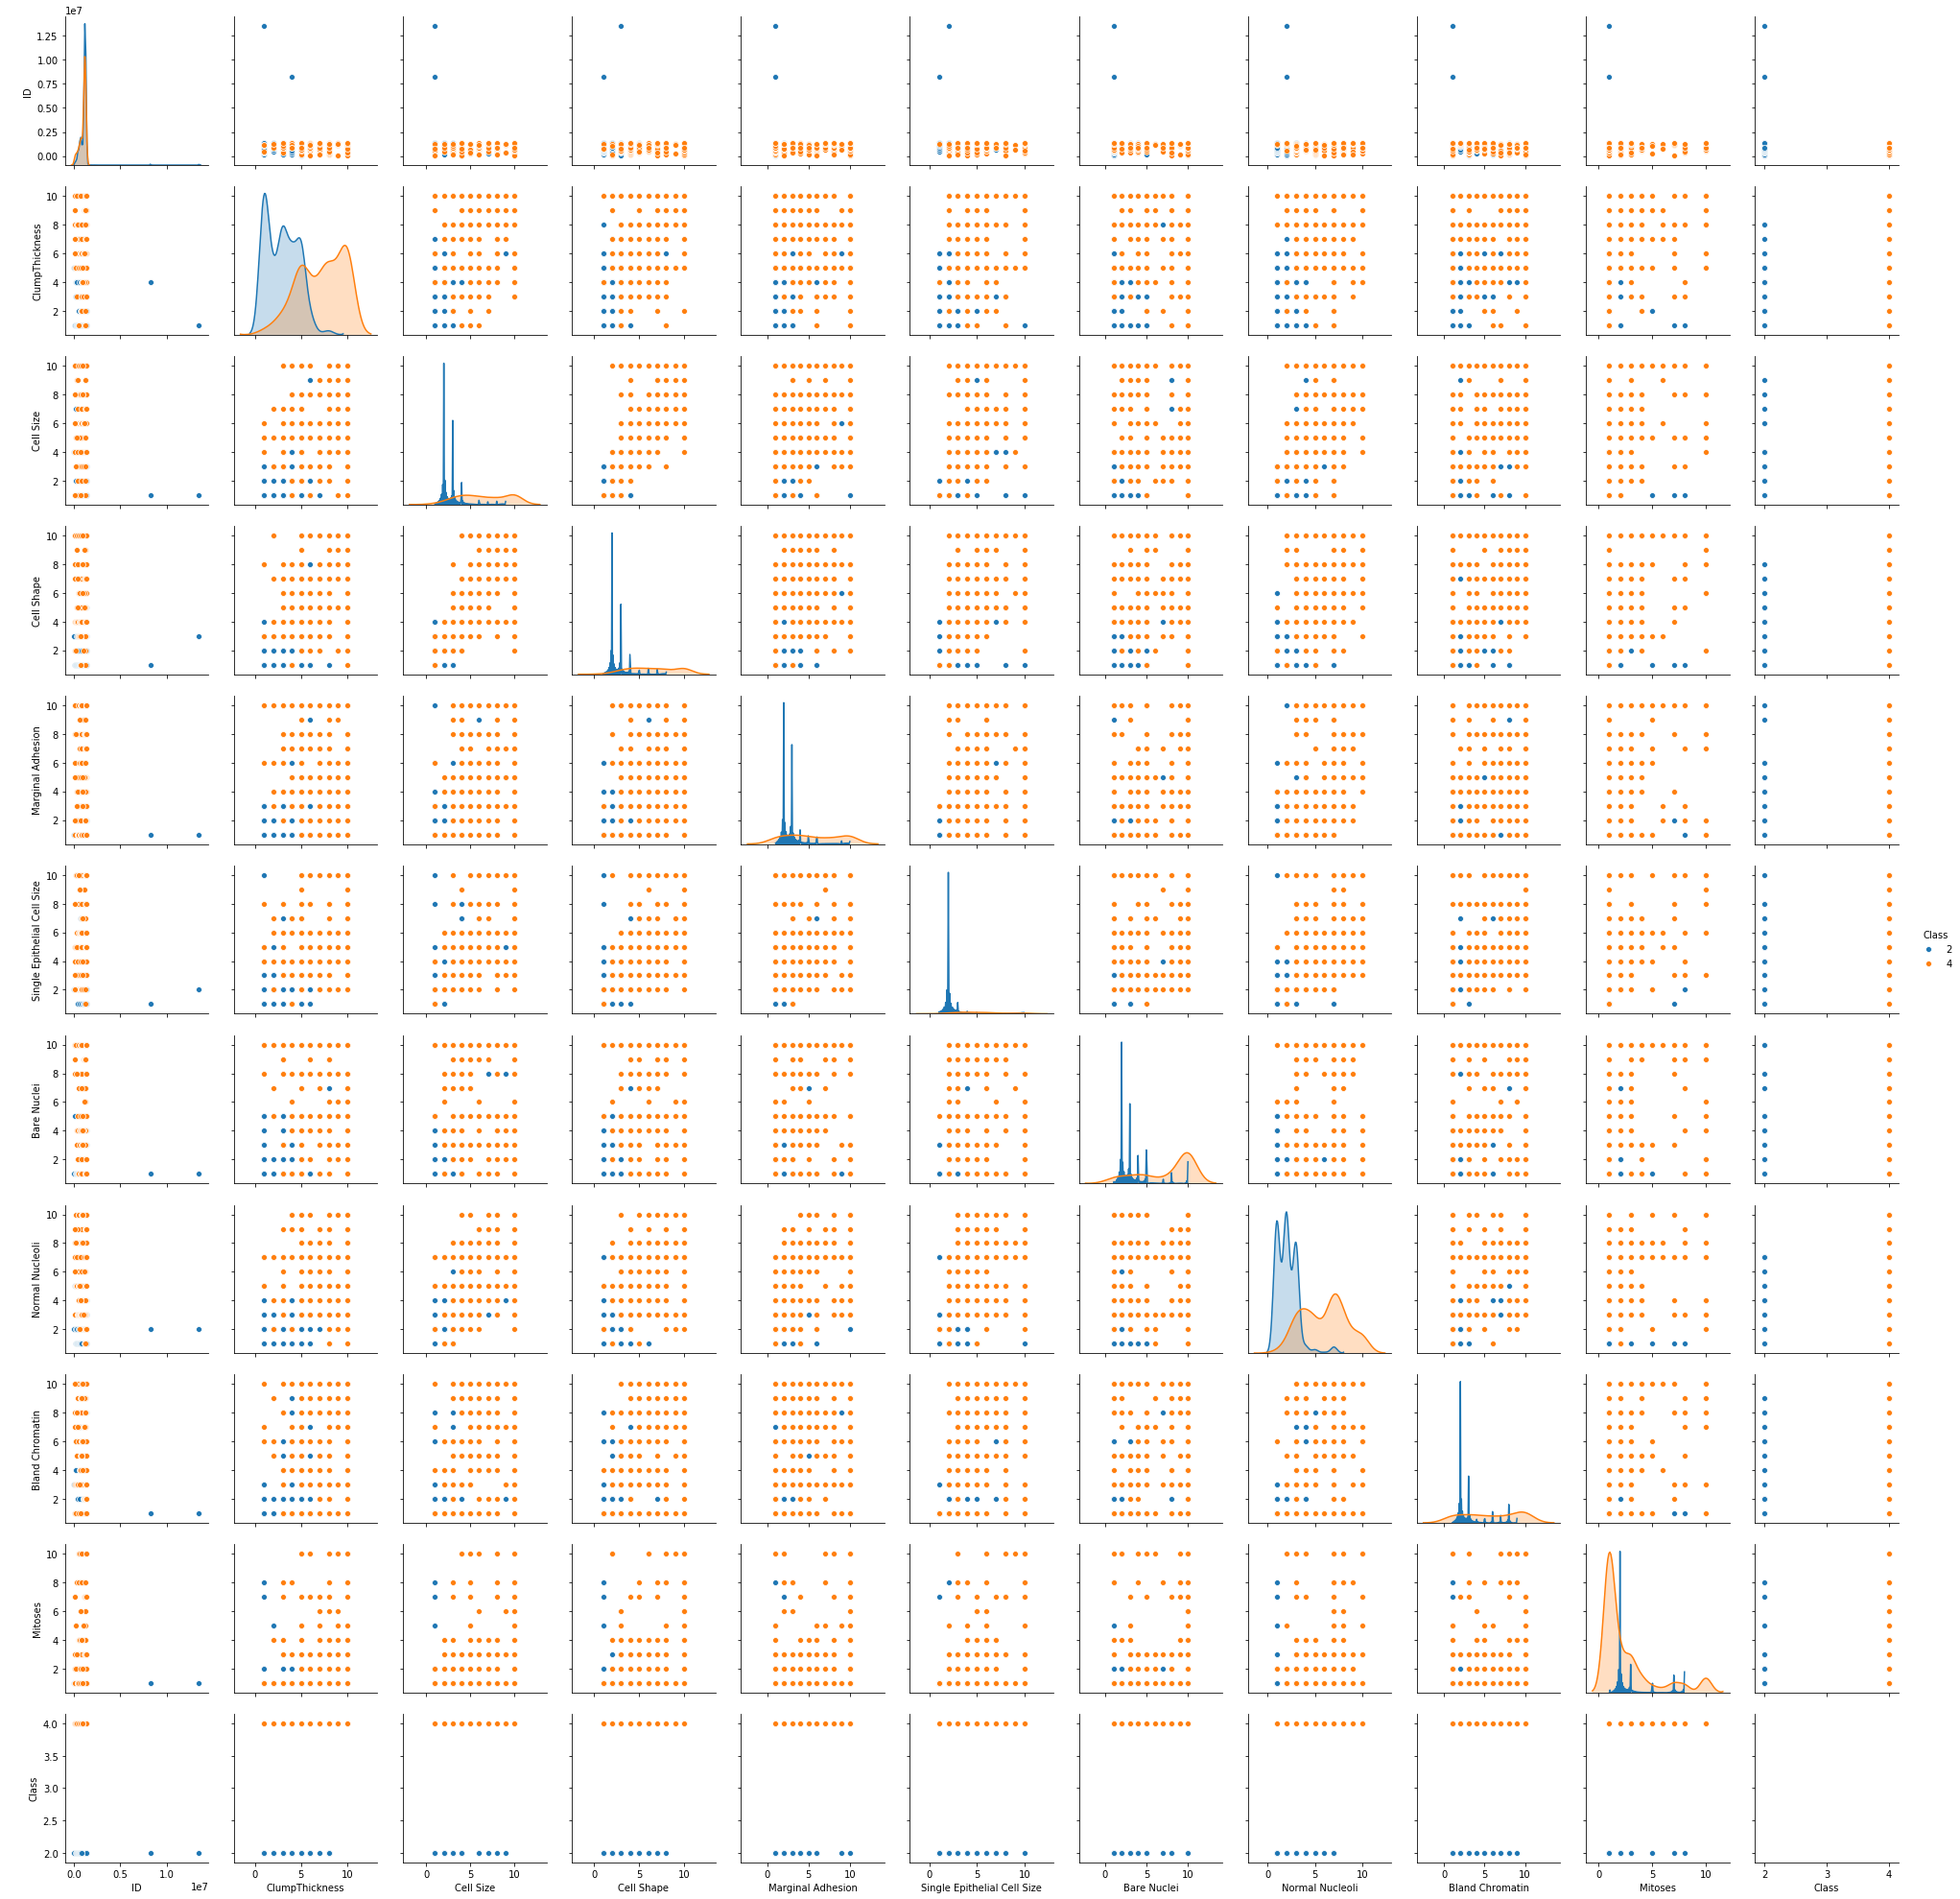

In [76]:
sns.pairplot(cancer_df, hue = 'Class')


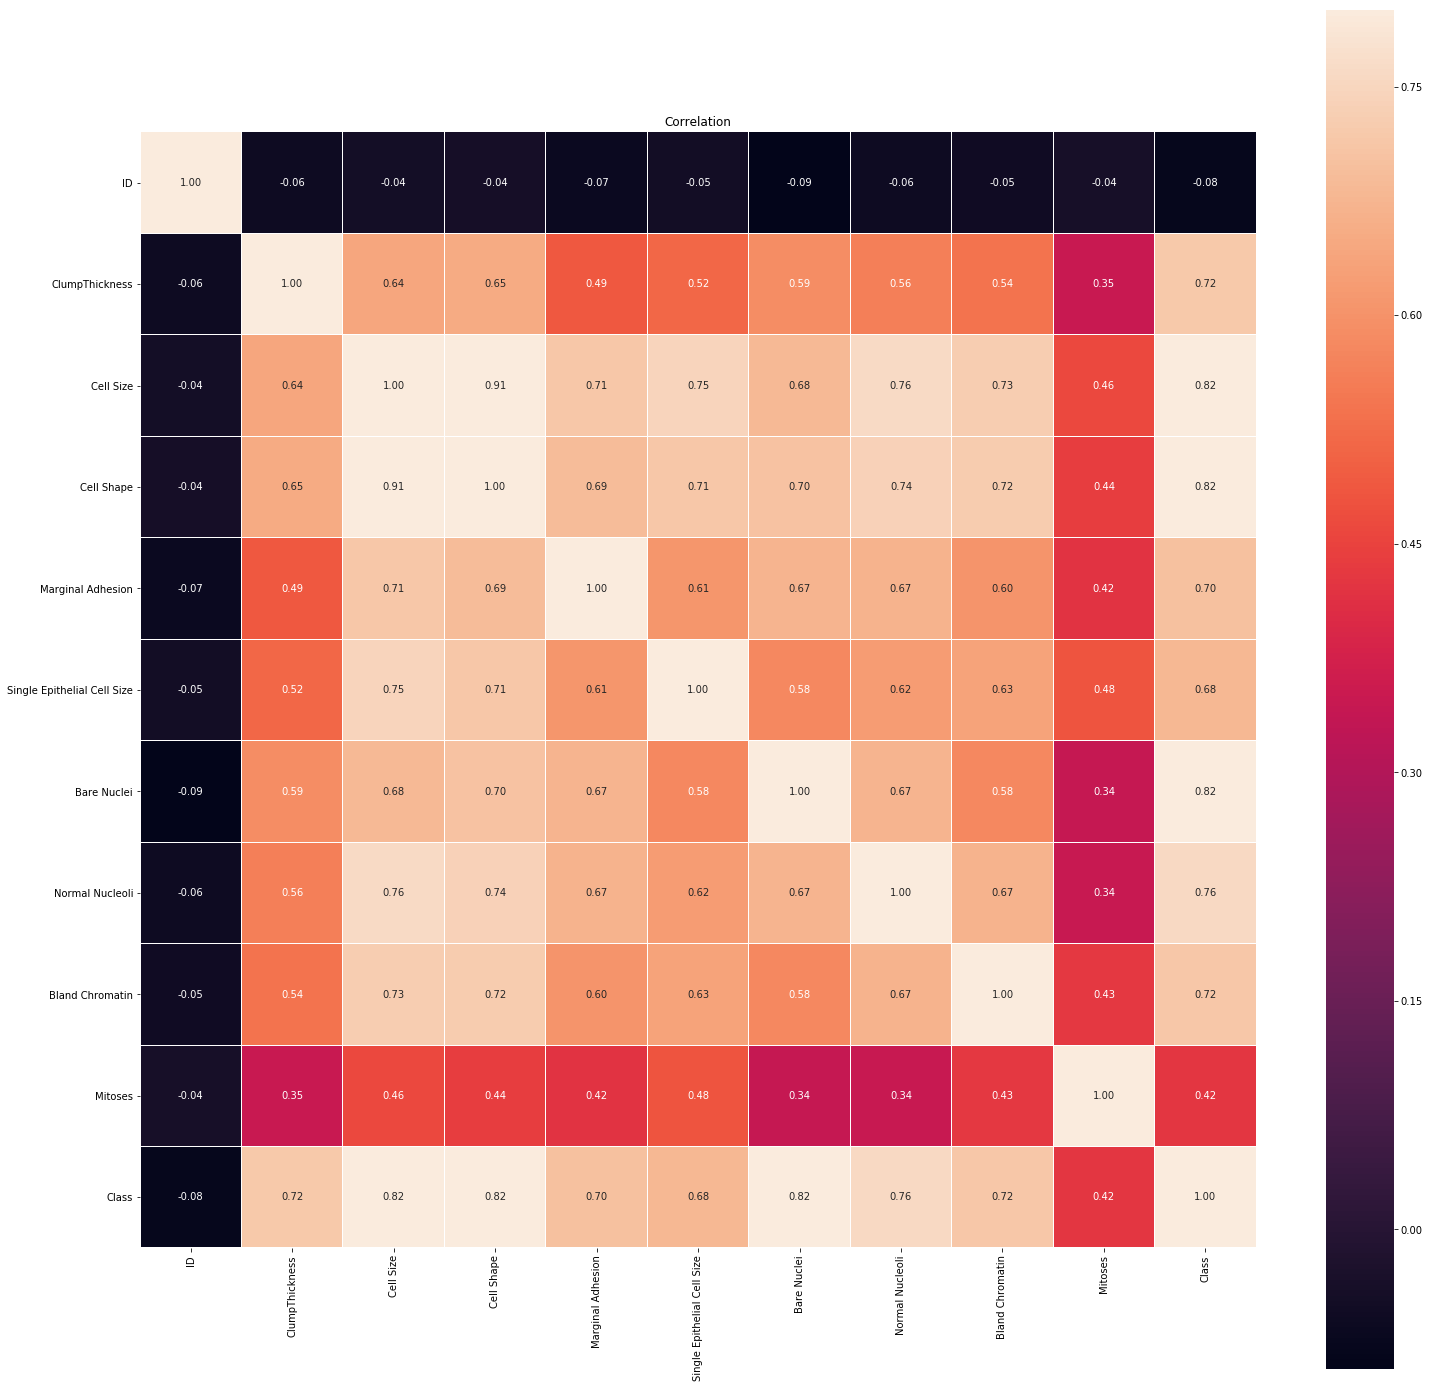

In [77]:
plt.figure(figsize=(25, 25))
ax = sns.heatmap(cancer_df.corr(), vmax=.8, square=True, fmt='.2f', annot=True, linecolor='white', linewidths=0.01)
plt.title('Correlation')
plt.show()

# Q5 Remove any unwanted columns or outliers, standardize variables in this pre-processing step

In [36]:
# We could see most of the outliers are now removed.

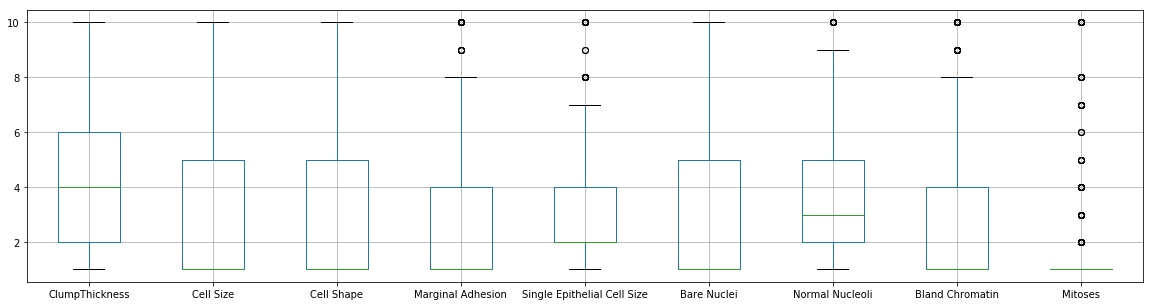

In [23]:
#Box-plot for all column
fig, ax = plt.subplots(figsize=(20,  5))
boxplot = cancer_df.boxplot(column=['ClumpThickness', 'Cell Size', 'Cell Shape','Marginal Adhesion','Single Epithelial Cell Size','Bare Nuclei','Normal Nucleoli','Bland Chromatin','Mitoses'],grid=True,ax=ax)

In [39]:
print("Marginal Adhesion - 75 percentile value : {0}".format(np.percentile(cancer_df['Marginal Adhesion'],75)))
print("Single Epithelial Cell Size - 75 percentile value : {0}".format(np.percentile(cancer_df['Single Epithelial Cell Size'],75)))
print("Normal Nucleoli - 75 percentile value : {0}".format(np.percentile(cancer_df['Normal Nucleoli'],75)))
print("Bland Chromatin - 75 percentile value : {0}".format(np.percentile(cancer_df['Bland Chromatin'],75)))
print("Mitoses - 95 percentile value : {0}".format(np.percentile(cancer_df['Mitoses'],95)))

Marginal Adhesion - 75 percentile value : 4.0
Single Epithelial Cell Size - 75 percentile value : 4.0
Normal Nucleoli - 75 percentile value : 5.0
Bland Chromatin - 75 percentile value : 4.0
Mitoses - 95 percentile value : 5.0


In [41]:
# Replace Outlier in the Cancer Data:

# Note : As per best practice  we should consider with domain expert to replace or remove outlier. 
#Sometime outlier make some meaningful in the data.

# In this case, when look above box plot we have outlier in the "Marginal Adhesion", "Single Epithelial Cell Size",
# "Normal Nucleoli", "Bland Chromatin", "Mitoses".
# Looks all outerlier only upper quartile range, so we will take 75 percentile value and replace the outlier 
#if data point greater than 75 percentile and replace with 75 percentile value

# In 'Marginal Adhesion' the 75 percentile value is  4
cancer_df['Marginal Adhesion'] = np.where(cancer_df['Marginal Adhesion'] > 4, 4, cancer_df['Marginal Adhesion'])
# In 'Single Epithelial Cell Size' the 75 percentile value is  4
cancer_df['Single Epithelial Cell Size'] = np.where(cancer_df['Single Epithelial Cell Size'] > 4, 4, cancer_df['Single Epithelial Cell Size'])
# In 'Normal Nucleoli' the 75 percentile value is  5
cancer_df['Normal Nucleoli'] = np.where(cancer_df['Normal Nucleoli'] > 5, 5, cancer_df['Normal Nucleoli'])
# In 'Bland Chromatin' the 75 percentile value is  4
cancer_df['Bland Chromatin'] = np.where(cancer_df['Bland Chromatin'] > 4, 4, cancer_df['Bland Chromatin'])
# In 'Mitoses' the 95 percentile value is  4. since value 1 to 5 falling in 95 percentile.
cancer_df['Mitoses'] = np.where(cancer_df['Mitoses'] > 5, 5, cancer_df['Mitoses'])


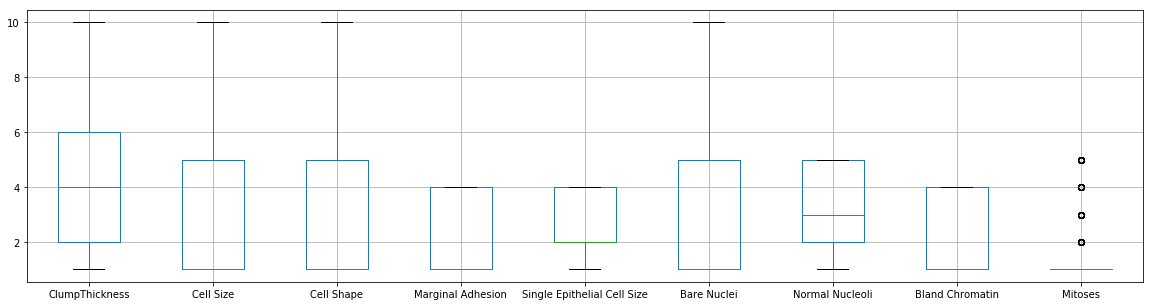

In [63]:
#Box-plot for all column. After removing the outlier
fig, ax = plt.subplots(figsize=(20,  5))
boxplot = cancer_df.boxplot(column=['ClumpThickness', 'Cell Size', 'Cell Shape','Marginal Adhesion','Single Epithelial Cell Size','Bare Nuclei','Normal Nucleoli','Bland Chromatin','Mitoses'],grid=True,ax=ax)

In [42]:
#Drop 'ID', 'Class' features
X = cancer_df.drop(["Class"], axis=1)
# Get Target variable in y
y = cancer_df["Class"]

In [43]:
#Standardize
# We transform (centralize) the entire X (independent variable data) to zscores through transformation. We will create the PCA dimensions
# on this distribution. 
sc = StandardScaler()
X_std =  sc.fit_transform(X)  
X_std

C:\ProgramData\Anaconda3\lib\site-packages\sklearn\preprocessing\data.py:625: DataConversionWarning: Data with input dtype int64 were all converted to float64 by StandardScaler.
  return self.partial_fit(X, y)
C:\ProgramData\Anaconda3\lib\site-packages\sklearn\base.py:462: DataConversionWarning: Data with input dtype int64 were all converted to float64 by StandardScaler.
  return self.fit(X, **fit_params).transform(X)


array([[-0.11919494,  0.20282286, -0.70169775, ...,  0.07775768,
        -0.71830997, -0.40086369],
       [-0.11447887,  0.20282286,  0.28506471, ...,  0.07775768,
         0.04655713, -0.40086369],
       [-0.09432253, -0.50757194, -0.70169775, ...,  0.07775768,
        -0.71830997, -0.40086369],
       ...,
       [-0.29880116,  0.20282286,  2.25858965, ...,  1.43605632,
         1.57629132,  0.53674969],
       [-0.28482901, -0.15237454,  1.600748  , ...,  1.43605632,
         1.57629132, -0.40086369],
       [-0.28482901, -0.15237454,  1.600748  , ...,  1.43605632,
         1.57629132, -0.40086369]])

# Q6 Create a covariance matrix for identifying Principal components

In [44]:
# PCA
# Step 1 - Create covariance matrix
cov_matrix = np.cov(X_std.T)
print('Covariance Matrix \n%s', cov_matrix)

Covariance Matrix 
%s [[ 1.00145138 -0.05967872 -0.04391921 -0.042865   -0.06236535 -0.08299465
  -0.0919656  -0.07221283 -0.07992104 -0.04747459]
 [-0.05967872  1.00145138  0.64410677  0.65453792  0.55329897  0.58388619
   0.59150555  0.5762575   0.57214901  0.39029196]
 [-0.04391921  0.64410677  1.00145138  0.9066632   0.72204998  0.77320789
   0.68556472  0.71799205  0.72684553  0.49803632]
 [-0.042865    0.65453792  0.9066632   1.00145138  0.7042574   0.75066888
   0.70518656  0.7033365   0.71910723  0.47407116]
 [-0.06236535  0.55329897  0.72204998  0.7042574   1.00145138  0.6955125
   0.69693138  0.65110177  0.65326018  0.39717024]
 [-0.08299465  0.58388619  0.77320789  0.75066888  0.6955125   1.00145138
   0.68280195  0.67626384  0.72360753  0.43890119]
 [-0.0919656   0.59150555  0.68556472  0.70518656  0.69693138  0.68280195
   1.00145138  0.6894512   0.64168219  0.41400928]
 [-0.07221283  0.5762575   0.71799205  0.7033365   0.65110177  0.67626384
   0.6894512   1.00145138  0.6

# Q7 Identify eigen values and eigen vector

In [42]:
# Step 2- Get eigen values and eigen vector

In [45]:
eigenvalues, eigenvectors = np.linalg.eig(cov_matrix)
print('Eigen Vectors \n%s', eigenvectors)
print('\n Eigen Values \n%s', eigenvalues)

Eigen Vectors 
%s [[ 3.81146790e-02  9.95884915e-01  1.05617868e-02 -1.19359758e-04
   1.39009703e-02 -4.55680366e-02 -1.31646867e-02  2.80509595e-02
  -4.28880064e-02  3.97455977e-02]
 [-3.04894876e-01  1.36714568e-02  2.64142301e-02 -1.65682815e-02
  -9.19483207e-01 -5.12806397e-02 -8.68482166e-02 -7.69505981e-02
  -1.98998971e-02  2.09620851e-01]
 [-3.69863325e-01  5.76331030e-02  3.62266819e-03 -7.27178528e-01
   2.16146032e-02  3.34528052e-01  1.22738781e-01 -3.43149313e-02
   2.71244591e-01 -3.59006478e-01]
 [-3.66980140e-01  5.80026324e-02  3.23452317e-02  6.73803317e-01
  -3.30941250e-02  3.03048559e-01  2.72734225e-01  5.66465653e-02
   2.77406571e-01 -3.99278476e-01]
 [-3.36159951e-01  1.37534227e-02  1.54626697e-01  4.65834781e-02
   2.49048595e-01 -3.84085614e-01 -3.53115045e-02 -5.74374055e-01
   4.71806654e-01  3.12132915e-01]
 [-3.50599206e-01 -6.76906845e-03  7.64679632e-02  6.48547513e-02
   1.90156792e-01  2.24544293e-01 -7.04661947e-01  4.48710436e-01
   1.23201556e-

In [46]:
# Step 3 (continued): Sort eigenvalues in descending order

# Make a set of (eigenvalue, eigenvector) pairs
eig_pairs = [(eigenvalues[index], eigenvectors[:,index]) for index in range(len(eigenvalues))]

# Sort the (eigenvalue, eigenvector) pairs from highest to lowest with respect to eigenvalue
eig_pairs.sort()

eig_pairs.reverse()
print(eig_pairs)

# Extract the descending ordered eigenvalues and eigenvectors
eigvalues_sorted = [eig_pairs[index][0] for index in range(len(eigenvalues))]
eigvectors_sorted = [eig_pairs[index][1] for index in range(len(eigenvalues))]

# Let's confirm our sorting worked, print out eigenvalues
print('Eigenvalues in descending order: \n%s' %eigvalues_sorted)

[(6.089782740362326, array([ 0.03811468, -0.30489488, -0.36986333, -0.36698014, -0.33615995,
       -0.35059921, -0.33755174, -0.33661395, -0.34136327, -0.23326113])), (0.9983587483501657, array([ 0.99588491,  0.01367146,  0.0576331 ,  0.05800263,  0.01375342,
       -0.00676907, -0.0305084 , -0.00155508, -0.00787981,  0.01049756])), (0.7231538965369658, array([ 0.01056179,  0.02641423,  0.00362267,  0.03234523,  0.1546267 ,
        0.07646796,  0.13385519,  0.20774965,  0.02157503, -0.95227728])), (0.4917943316271548, array([ 0.01390097, -0.91948321,  0.0216146 , -0.03309412,  0.24904859,
        0.19015679,  0.05747723,  0.10473782,  0.19018215,  0.06455448])), (0.3983316545813707, array([-0.04556804, -0.05128064,  0.33452805,  0.30304856, -0.38408561,
        0.22454429, -0.6605872 , -0.10546239,  0.3546742 , -0.14252351])), (0.3643074510690591, array([-0.04288801, -0.0198999 ,  0.27124459,  0.27740657,  0.47180665,
        0.12320156, -0.06624768, -0.65577866, -0.4131481 , -0.06580

# Q8 Find variance and cumulative variance by each eigen vector

In [47]:
tot = sum(eigenvalues)
# an array of variance explained by each 
# eigen vector... there will be 9 entries as there are 9 eigen vectors)
var_explained = [(i / tot) for i in sorted(eigenvalues, reverse=True)] 
print("Variance Explained: \n", var_explained)
cum_var_exp = np.cumsum(var_explained)  # an array of cumulative variance. There will be 9 entries with 8 th entry 
# cumulative reaching almost 100%
print("Cumulative Variance: \n", cum_var_exp)

Variance Explained: 
 [0.6080956968274841, 0.0996911851613426, 0.07221058474115497, 0.049108158621899926, 0.03977543623283541, 0.036377946925591535, 0.03191969807866368, 0.0283870680602151, 0.025354797584350323, 0.009079427766462164]
Cumulative Variance: 
 [0.6080957  0.70778688 0.77999747 0.82910563 0.86888106 0.90525901
 0.93717871 0.96556577 0.99092057 1.        ]


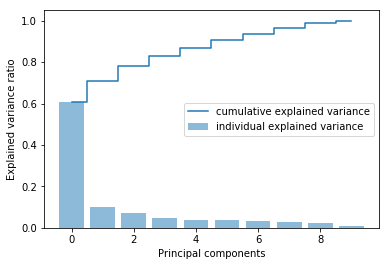

In [51]:
plt.bar(range(0,10), var_explained, alpha=0.5, align='center', label='individual explained variance')
plt.step(range(0,10),cum_var_exp, where= 'mid', label='cumulative explained variance')
plt.ylabel('Explained variance ratio')
plt.xlabel('Principal components')
plt.legend(loc = 'best')
plt.show()

# Q9 Use PCA command from sklearn and find Principal Components. Transform data to components formed

In [52]:
from sklearn.decomposition import PCA

In [53]:
#PCA components has been selected as 7 as per explained variance ratio which contain ~93% of variance
pca = PCA(n_components=7)
pca.fit(X_std)

PCA(copy=True, iterated_power='auto', n_components=7, random_state=None,
  svd_solver='auto', tol=0.0, whiten=False)

In [54]:
X_pca = pca.transform(X_std)

In [55]:
X_pca.shape

(690, 7)

In [56]:
#PCA Components
pca.components_

array([[-0.03811468,  0.30489488,  0.36986333,  0.36698014,  0.33615995,
         0.35059921,  0.33755174,  0.33661395,  0.34136327,  0.23326113],
       [ 0.99588491,  0.01367146,  0.0576331 ,  0.05800263,  0.01375342,
        -0.00676907, -0.0305084 , -0.00155508, -0.00787981,  0.01049756],
       [-0.01056179, -0.02641423, -0.00362267, -0.03234523, -0.1546267 ,
        -0.07646796, -0.13385519, -0.20774965, -0.02157503,  0.95227728],
       [-0.01390097,  0.91948321, -0.0216146 ,  0.03309412, -0.24904859,
        -0.19015679, -0.05747723, -0.10473782, -0.19018215, -0.06455448],
       [-0.04556804, -0.05128064,  0.33452805,  0.30304856, -0.38408561,
         0.22454429, -0.6605872 , -0.10546239,  0.3546742 , -0.14252351],
       [ 0.04288801,  0.0198999 , -0.27124459, -0.27740657, -0.47180665,
        -0.12320156,  0.06624768,  0.65577866,  0.4131481 ,  0.06580793],
       [-0.0397456 , -0.20962085,  0.35900648,  0.39927848, -0.31213291,
        -0.25948604,  0.09942702,  0.40193677

In [57]:
pca.components_.shape

(7, 10)

In [58]:
pca.explained_variance_

array([6.08978274, 0.99835875, 0.7231539 , 0.49179433, 0.39833165,
       0.36430745, 0.31966026])

In [59]:
pca.explained_variance_ratio_

array([0.6080957 , 0.09969119, 0.07221058, 0.04910816, 0.03977544,
       0.03637795, 0.0319197 ])

# Q10 Find correlation between components and features

In [60]:
df = pd.DataFrame(X_pca)

C:\ProgramData\Anaconda3\lib\site-packages\scipy\stats\stats.py:1713: FutureWarning: Using a non-tuple sequence for multidimensional indexing is deprecated; use `arr[tuple(seq)]` instead of `arr[seq]`. In the future this will be interpreted as an array index, `arr[np.array(seq)]`, which will result either in an error or a different result.
  return np.add.reduce(sorted[indexer] * weights, axis=axis) / sumval
C:\ProgramData\Anaconda3\lib\site-packages\statsmodels\nonparametric\kde.py:488: RuntimeWarning: invalid value encountered in true_divide
  binned = fast_linbin(X, a, b, gridsize) / (delta * nobs)
C:\ProgramData\Anaconda3\lib\site-packages\statsmodels\nonparametric\kdetools.py:34: RuntimeWarning: invalid value encountered in double_scalars
  FAC1 = 2*(np.pi*bw/RANGE)**2
C:\ProgramData\Anaconda3\lib\site-packages\numpy\core\fromnumeric.py:83: RuntimeWarning: invalid value encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)


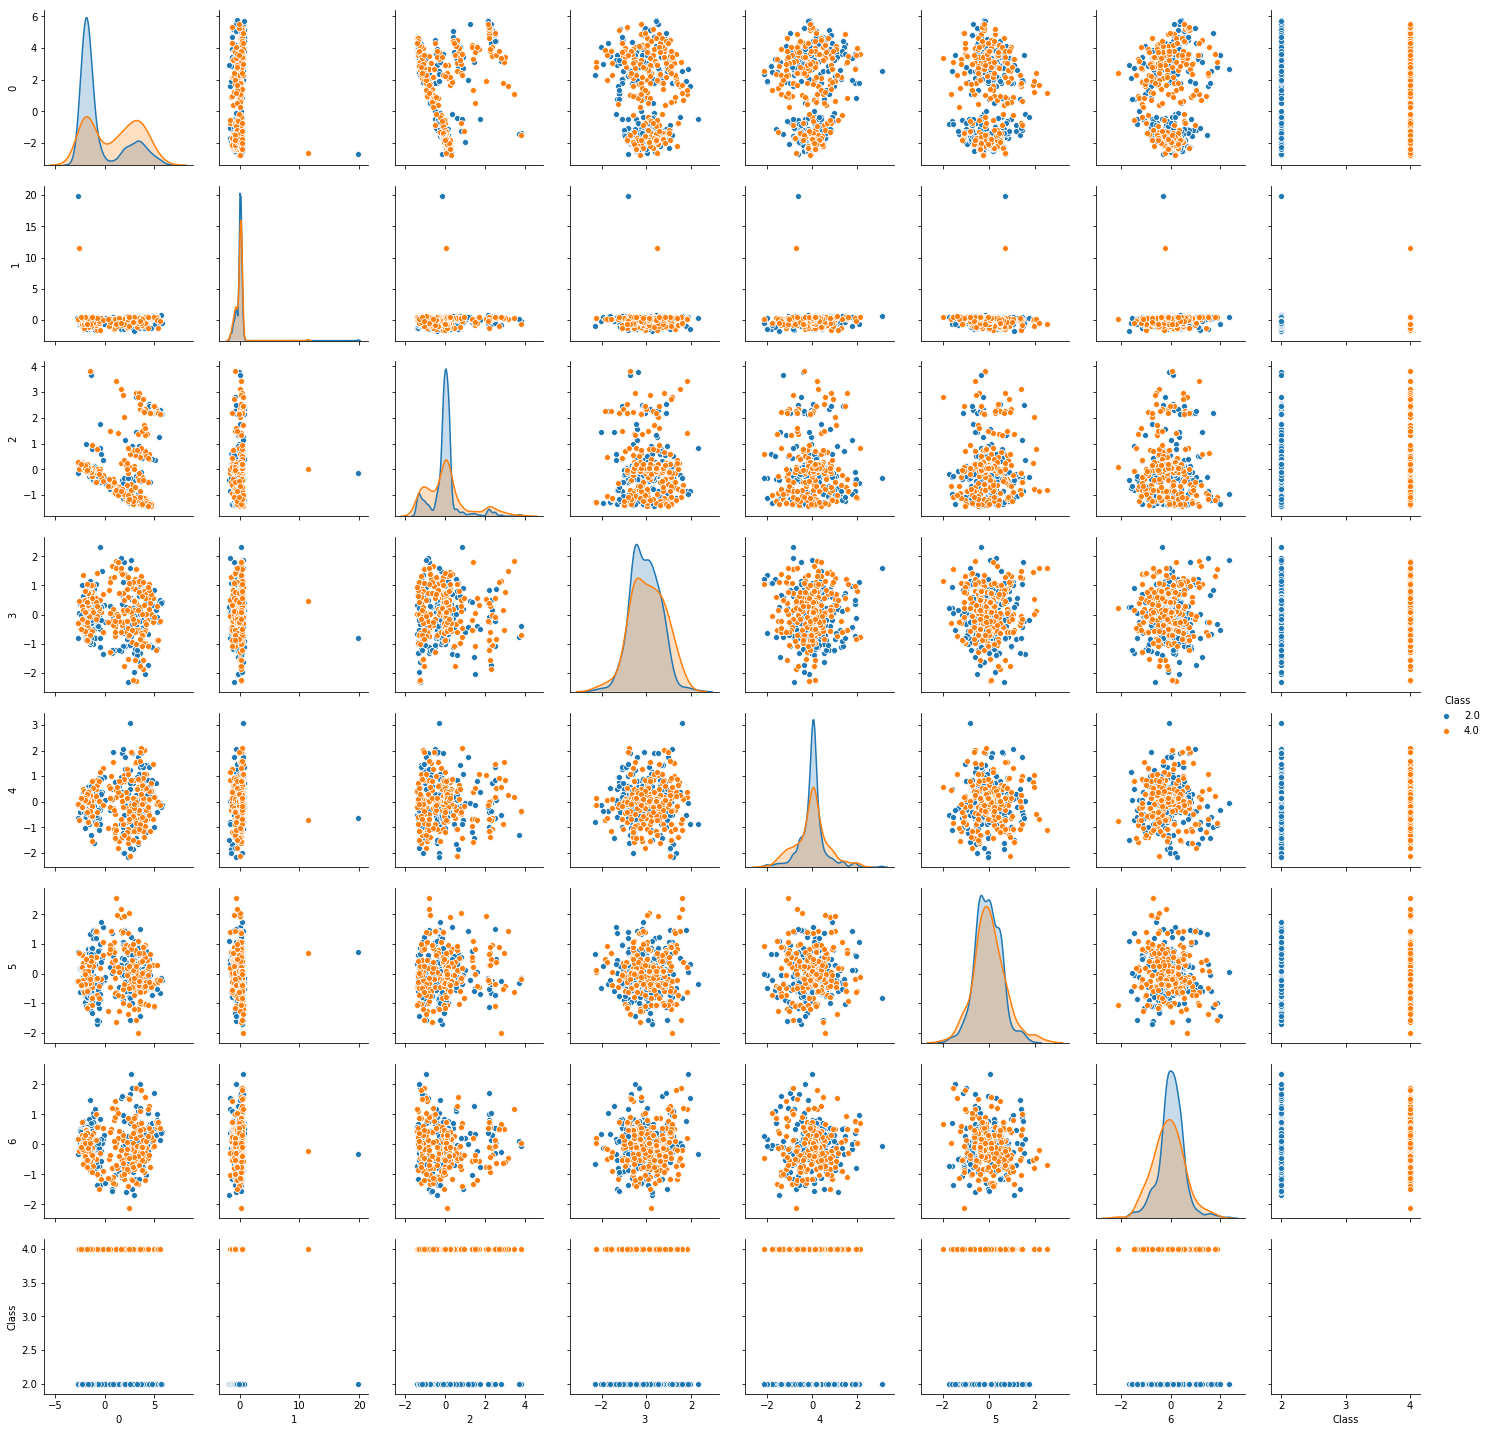

In [61]:
df = df.join(y)
#Pair plot with PCA data
sns.pairplot(df, diag_kind='kde',hue='Class') 

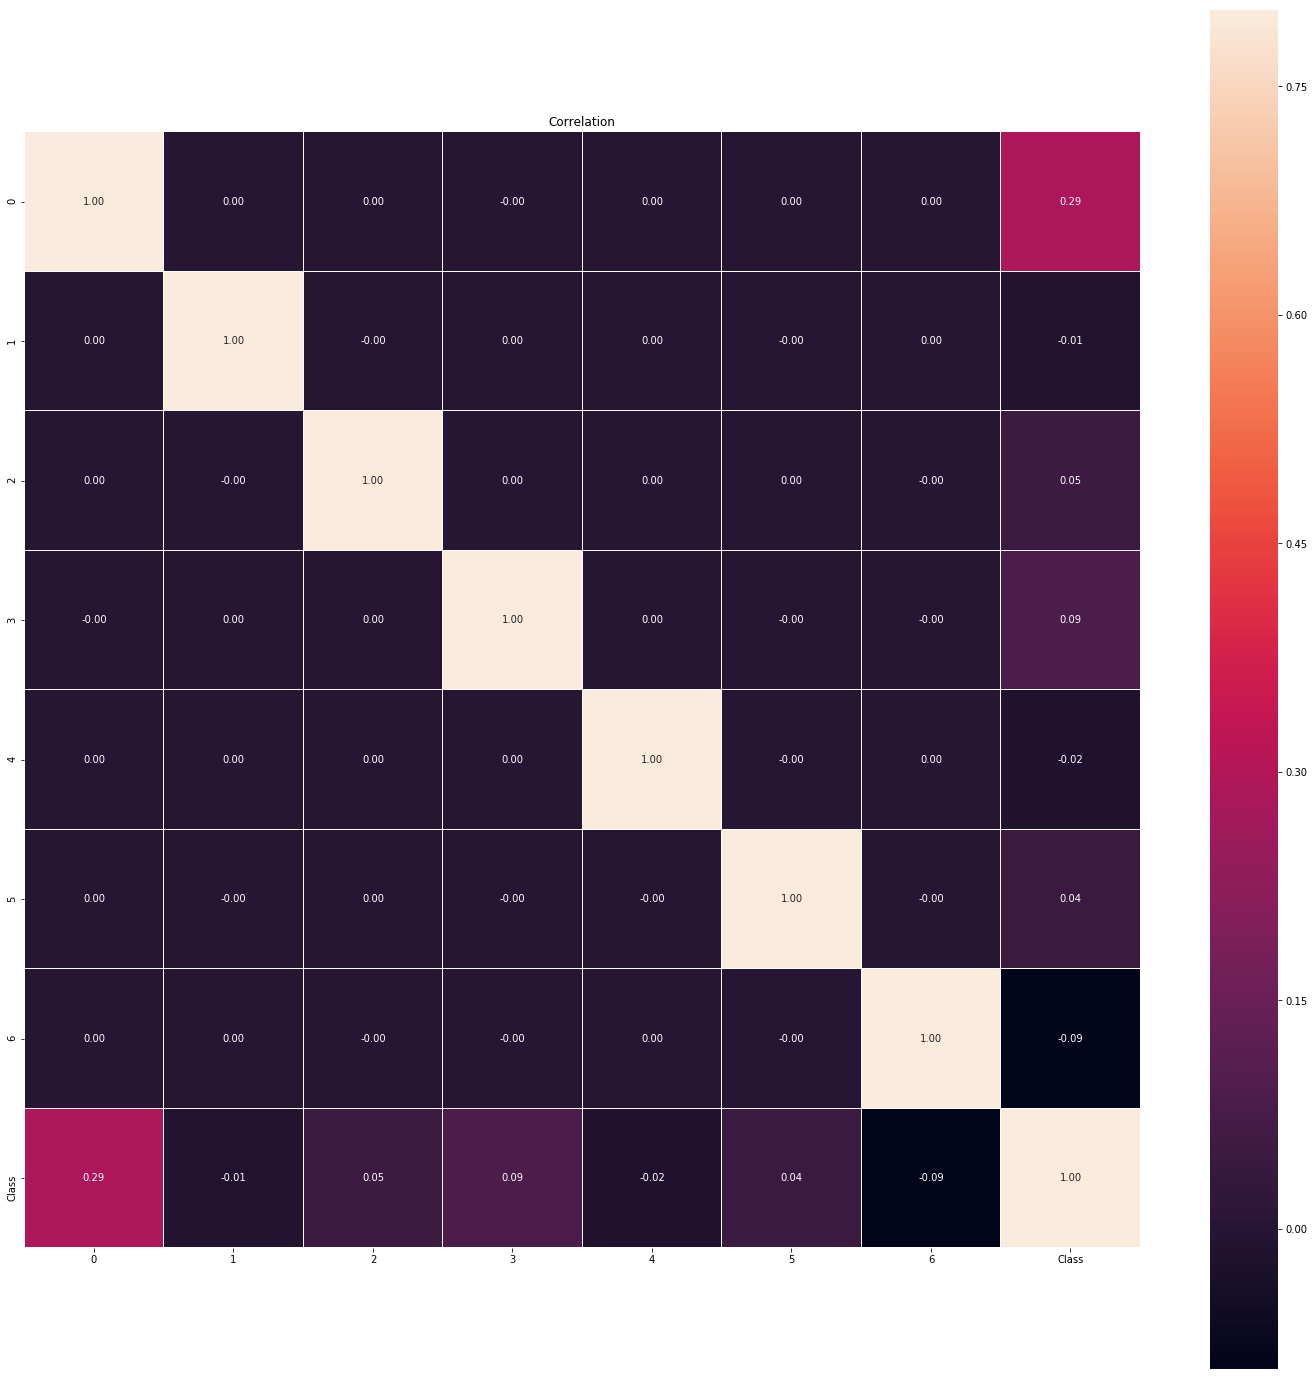

In [62]:
#Correlation Matrix After PCA
plt.figure(figsize=(25, 25))
ax = sns.heatmap(df.corr(), vmax=.8, square=True, fmt='.2f', annot=True, linecolor='white', linewidths=0.01)
plt.title('Correlation')
plt.show()